In this assignment, you must implement an ACO version to solve the **vehicle routing problem**.

*Capacitated Vehicle Routing Problem (CVRP)*: is a vehicle routing problem in which a fleet of identical vehicles of finite capacity and located at a central depot must service a set of customers with known demands. The objective is to determine a set of vehicle trips of minimum total cost (sum of travel distance or time), such that each vehicle starts and ends at the depot, each client is visited exactly once, and the total demand handled by any vehicle does not exceed its capacity.

*Data*: cvrp.txt
- first line: vehicle capacity
- second line (depot): x-coordinate, y-coordinate
- remaining lines (customers): x coordinate, y coordinate, demand

You can consider that a delivery doesn't take any time, i.e., the total cost is calculated based on the distance travelled. Also, the vehicles do not have a time threshold, i.e., each vehicle can travel for as long as you want.

# Set up

In [ ]:
# imports
import math
import random
import matplotlib.pyplot as plt
import itertools
from typing import List, Tuple
import time

In [115]:
# parsing the input file
def parse_input_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        vehicle_capacity = int(lines[0].strip())
        depot = tuple(map(float, lines[1].strip().split()))
        customers = []
        for line in lines[2:]:
            parts = line.strip().split()
            x = float(parts[0])
            y = float(parts[1])
            demand = int(parts[2])
            customers.append((x, y, demand))
    return vehicle_capacity, depot, customers

In [116]:
file_path = 'cvrp.txt'
vehicle_capacity, depot, customers = parse_input_file(file_path)
print(f"Vehicle Capacity: {vehicle_capacity}")
print(f"Depot: {depot}")
print(f"Customers: {customers}")

Node = Tuple[float, float]
Customer = Tuple[float, float, float] # x, y, demand
Route = List[int]

Vehicle Capacity: 160
Depot: (30.0, 40.0)
Customers: [(37.0, 52.0, 7), (49.0, 49.0, 30), (52.0, 64.0, 16), (20.0, 26.0, 9), (40.0, 30.0, 21), (21.0, 47.0, 15), (17.0, 63.0, 19), (31.0, 62.0, 23), (52.0, 33.0, 11), (51.0, 21.0, 5), (42.0, 41.0, 19), (31.0, 32.0, 29), (5.0, 25.0, 23), (12.0, 42.0, 21), (36.0, 16.0, 10), (52.0, 41.0, 15), (27.0, 23.0, 3), (17.0, 33.0, 41), (13.0, 13.0, 9), (57.0, 58.0, 28), (62.0, 42.0, 8), (42.0, 57.0, 8), (16.0, 57.0, 16), (8.0, 52.0, 10), (7.0, 38.0, 28), (27.0, 68.0, 7), (30.0, 48.0, 15), (43.0, 67.0, 14), (58.0, 48.0, 6), (58.0, 27.0, 19), (37.0, 69.0, 11), (38.0, 46.0, 12), (46.0, 10.0, 23), (61.0, 33.0, 26), (62.0, 63.0, 17), (63.0, 69.0, 6), (32.0, 22.0, 9), (45.0, 35.0, 15), (59.0, 15.0, 14), (5.0, 6.0, 7), (10.0, 17.0, 27), (21.0, 10.0, 13), (5.0, 64.0, 11), (30.0, 15.0, 16), (39.0, 10.0, 10), (32.0, 39.0, 5), (25.0, 32.0, 25), (25.0, 55.0, 17), (48.0, 28.0, 18), (56.0, 37.0, 10)]


In [117]:
# plotting the depot and customers
def plot_cvrp(depot, customers):
    plt.figure(figsize=(8, 6))
    plt.scatter(depot[0], depot[1], c='red', marker='s', label='Depot')
    for customer in customers:
        plt.scatter(customer[0], customer[1], c='blue', marker='o', label='Customer')
    plt.title('CVRP Depot and Customers')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

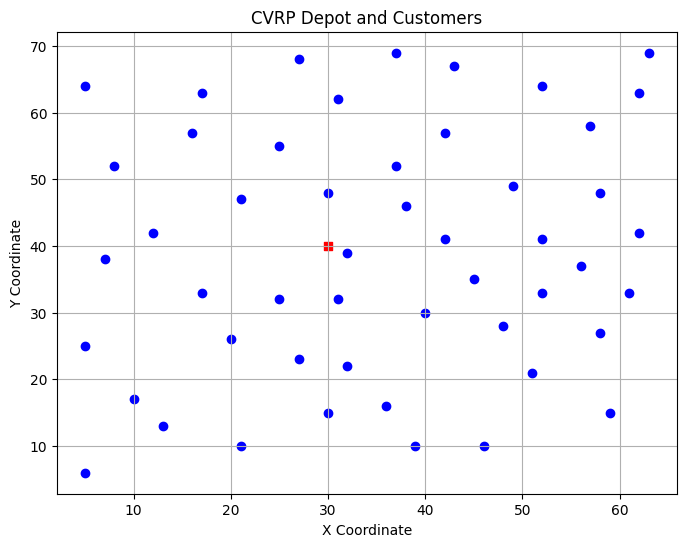

In [118]:
plot_cvrp(depot, customers)

In [119]:
def plot_routes(depot: Node, customers: List[Customer], routes: List[Route]):
    plt.figure(figsize=(8, 6))
    plt.scatter(depot[0], depot[1], c='red', marker='s', label='Depot')
    
    for customer in customers:
        plt.scatter(customer[0], customer[1], c='blue', marker='o', label='Customer')
    
    colors = ['green', 'orange', 'purple', 'cyan', 'magenta']
    for i, route in enumerate(routes):
        route_nodes = [0] + route + [0] # Start and end at depot
        route_coords = [(depot[0], depot[1])] + [(customers[node-1][0], customers[node-1][1]) for node in route] + [(depot[0], depot[1])]
        xs, ys = zip(*route_coords)
        plt.plot(xs, ys, color=colors[i % len(colors)], label=f'Route {i+1}')
    
    plt.title('CVRP Routes')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

## Algorithm
### GRASP (Greedy Randomized Adaptive Search Procedures)
- builds distance matrix of all nodes first
- route cost is calculated by summing over all the distances in a route
- randomized greedy search: find all feasible customers (that are within the capacity of the vehicle in the route), if no more feasible return to depot, calculate the cost of feasible next costumers, parameter alpha defines a threshold within the range of costs, build restricted candidate list, choose of of them at random
- 2-opt local search: trys every combination of swapping 2 nodes to see if the result improves ("untangles" the solution)

In [120]:
class GRASP_CVRP:
    def __init__(self, vehicle_capacity: float, depot: Node, customers: List[Customer]):
        self.capacity = vehicle_capacity
        self.depot = depot
        self.customers = customers
        
        # Node 0 is depot, 1 to N are customers
        self.nodes = [(depot[0], depot[1], 0.0)] + customers
        self.num_nodes = len(self.nodes)
        self.distance_matrix = self._build_distance_matrix()

    def _build_distance_matrix(self) -> List[List[float]]:
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    matrix[i][j] = math.dist(self.nodes[i][:2], self.nodes[j][:2])
        return matrix

    def calculate_route_cost(self, route: Route) -> float:
        cost = 0.0
        # Start from depot
        current_node = 0
        for node in route:
            cost += self.distance_matrix[current_node][node]
            current_node = node
        # Return to depot
        cost += self.distance_matrix[current_node][0]
        return cost

    def _construct_randomized_greedy_solution(self, alpha: float) -> List[Route]:
        unvisited = set(range(1, self.num_nodes))
        routes = []
        
        while unvisited:
            current_route = []
            current_load = 0.0
            current_node = 0 # Start at depot
            
            while unvisited:
                # Find feasible candidates (demand fits remaining capacity)
                feasible_candidates = [
                    c for c in unvisited 
                    if current_load + self.nodes[c][2] <= self.capacity
                ]
                
                if not feasible_candidates:
                    break # Vehicle is full, return to depot (end route)
                
                # Calculate costs for feasible candidates
                costs = {c: self.distance_matrix[current_node][c] for c in feasible_candidates}
                c_min = min(costs.values())
                c_max = max(costs.values())
                
                # Build Restricted Candidate List (RCL)
                threshold = c_min + alpha * (c_max - c_min)
                rcl = [c for c, cost in costs.items() if cost <= threshold]
                
                # Randomly pick from RCL
                next_node = random.choice(rcl)
                
                # Update state
                current_route.append(next_node)
                current_load += self.nodes[next_node][2]
                unvisited.remove(next_node)
                current_node = next_node
                
            routes.append(current_route)
            
        return routes

    def _local_search_2opt(self, route: Route) -> Route:
        """Applies 2-opt intra-route optimization to a single route."""
        best_route = route.copy()
        best_cost = self.calculate_route_cost(best_route)
        improved = True
        
        while improved:
            improved = False
            for i in range(1, len(best_route) - 2):
                for j in range(i + 1, len(best_route)):
                    if j - i == 1: continue # Skip adjacent edges
                    
                    # 2-opt swap
                    new_route = best_route[:]
                    new_route[i:j] = best_route[j-1:i-1:-1]
                    
                    new_cost = self.calculate_route_cost(new_route)
                    if new_cost < best_cost:
                        best_route = new_route
                        best_cost = new_cost
                        improved = True
        return best_route

    def solve(self, iterations: int = 50, alpha: float = 0.2) -> Tuple[List[Route], float]:
        best_all_routes = None
        best_total_cost = float('inf')

        for _ in range(iterations):
            # 1. Construction Phase
            routes = self._construct_randomized_greedy_solution(alpha)
            
            # 2. Local Search Phase (optimize each route individually)
            optimized_routes = []
            total_cost = 0.0
            
            for route in routes:
                opt_route = self._local_search_2opt(route)
                optimized_routes.append(opt_route)
                total_cost += self.calculate_route_cost(opt_route)
                
            # 3. Update Best Solution
            if total_cost < best_total_cost:
                best_total_cost = total_cost
                best_all_routes = optimized_routes
                
        return best_all_routes, best_total_cost

Best Cost: 764.8044067018919
Routes: [[11, 50, 34, 10, 49, 38, 5, 15, 12, 46], [17, 47, 4, 19, 41, 13, 25, 6, 14], [37, 44, 45, 33, 39, 30, 21, 29, 9, 18], [27, 32, 16, 2, 20, 3, 22, 8, 31], [23, 48, 1, 35, 36, 28, 26, 7, 43, 24, 42, 40]]


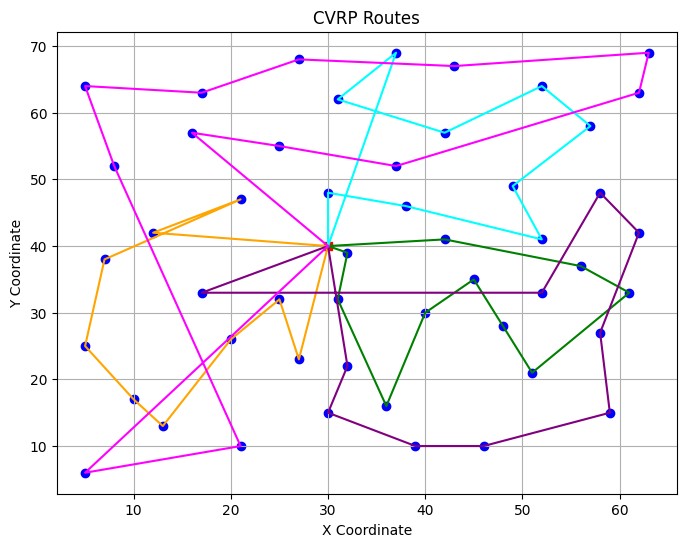

In [121]:
# Run GRASP
solver = GRASP_CVRP(vehicle_capacity, depot, customers)
best_routes, best_cost = solver.solve(iterations=100, alpha=0.3)
print(f"Best Cost: {best_cost}")
print(f"Routes: {best_routes}")
plot_routes(depot, customers, best_routes)

### AOC (Ant Colony Optimization)

In [122]:
# Type aliases
Node = Tuple[float, float]
Customer = Tuple[float, float, float] # x, y, demand
Route = List[int]
Solution = List[Route]

class ACO_CVRP:
    def __init__(self, vehicle_capacity: float, depot: Node, customers: List[Customer],
                 num_ants: int = 20, iterations: int = 100,
                 alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1, Q: float = 1.0):
        
        self.capacity = vehicle_capacity
        self.nodes = [(depot[0], depot[1], 0.0)] + customers
        self.num_nodes = len(self.nodes)
        
        # ACO Parameters
        self.num_ants = num_ants
        self.iterations = iterations
        self.alpha = alpha   # Pheromone importance
        self.beta = beta     # Heuristic importance
        self.rho = rho       # Evaporation rate
        self.Q = Q           # Deposit constant
        
        # Initialize Matrices
        self.distance_matrix = self._build_distance_matrix()
        self.heuristic_matrix = self._build_heuristic_matrix()
        
        # Initial pheromone value (tau_0). Often set to 1.0 / (num_nodes * greedy_cost)
        self.tau_0 = 0.1 
        self.pheromone_matrix = [[self.tau_0] * self.num_nodes for _ in range(self.num_nodes)]

    def _build_distance_matrix(self) -> List[List[float]]:
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j:
                    matrix[i][j] = math.dist(self.nodes[i][:2], self.nodes[j][:2])
        return matrix

    def _build_heuristic_matrix(self) -> List[List[float]]:
        """Calculates eta_ij = 1 / d_ij"""
        matrix = [[0.0] * self.num_nodes for _ in range(self.num_nodes)]
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                if i != j and self.distance_matrix[i][j] > 0:
                    matrix[i][j] = 1.0 / self.distance_matrix[i][j]
        return matrix

    def calculate_solution_cost(self, solution: Solution) -> float:
        """Sums the cost of all routes in a solution."""
        total_cost = 0.0
        for route in solution:
            current_node = 0
            for node in route:
                total_cost += self.distance_matrix[current_node][node]
                current_node = node
            total_cost += self.distance_matrix[current_node][0]
        return total_cost

    def _select_next_node(self, current_node: int, unvisited: set, current_load: float) -> int:
        """Calculates transition probabilities and selects the next node."""
        feasible_neighbors = [
            n for n in unvisited 
            if current_load + self.nodes[n][2] <= self.capacity
        ]
        
        # If no customer fits, the ant MUST return to the depot (node 0)
        if not feasible_neighbors:
            return 0
            
        probabilities = []
        denominator = 0.0
        
        # Calculate scores for feasible neighbors
        for j in feasible_neighbors:
            tau = self.pheromone_matrix[current_node][j] ** self.alpha
            eta = self.heuristic_matrix[current_node][j] ** self.beta
            score = tau * eta
            probabilities.append((j, score))
            denominator += score
            
        # Roulette wheel selection
        rand_val = random.random()
        cumulative_prob = 0.0
        
        for j, score in probabilities:
            prob = score / denominator
            cumulative_prob += prob
            if rand_val <= cumulative_prob:
                return j
                
        return feasible_neighbors[-1] # Fallback for floating point inaccuracies

    def _build_ant_solution(self) -> Solution:
        """Simulates one ant building a full CVRP solution."""
        unvisited = set(range(1, self.num_nodes))
        solution = []
        
        while unvisited:
            route = []
            current_load = 0.0
            current_node = 0 # Start at depot
            
            while unvisited:
                next_node = self._select_next_node(current_node, unvisited, current_load)
                
                if next_node == 0:
                    break # Capacity reached, end this route
                    
                route.append(next_node)
                current_load += self.nodes[next_node][2]
                unvisited.remove(next_node)
                current_node = next_node
                
            if route:
                solution.append(route)
                
        return solution

    def _update_pheromones(self, all_solutions: List[Tuple[Solution, float]], best_solution: Solution, best_cost: float):
        """Applies evaporation and Elitist deposit."""
        # 1. Evaporation (apply to all edges)
        for i in range(self.num_nodes):
            for j in range(self.num_nodes):
                self.pheromone_matrix[i][j] *= (1.0 - self.rho)
                
        # 2. Deposit (Elitist strategy: only the iteration's best ant deposits)
        deposit_amount = self.Q / best_cost
        # print(f"Depositing pheromone for best solution with cost {best_cost:.2f}, deposit amount: {deposit_amount:.4f}")
        
        for route in best_solution:
            current_node = 0
            for node in route:
                self.pheromone_matrix[current_node][node] += deposit_amount
                # If symmetric TSP/CVRP, update the reverse direction too:
                self.pheromone_matrix[node][current_node] += deposit_amount 
                current_node = node
            # Don't forget the return to depot
            self.pheromone_matrix[current_node][0] += deposit_amount
            self.pheromone_matrix[0][current_node] += deposit_amount

    def solve(self) -> Tuple[Solution, float]:
        global_best_solution = None
        global_best_cost = float('inf')
        
        for iteration in range(self.iterations):
            ant_solutions = []
            iteration_best_solution = None
            iteration_best_cost = float('inf')
            
            # Step 1: All ants build solutions
            for _ in range(self.num_ants):
                solution = self._build_ant_solution()
                cost = self.calculate_solution_cost(solution)
                ant_solutions.append((solution, cost))
                
                # Check for iteration best
                if cost < iteration_best_cost:
                    iteration_best_cost = cost
                    iteration_best_solution = solution
                    
            # Check for global best
            if iteration_best_cost < global_best_cost:
                global_best_cost = iteration_best_cost
                global_best_solution = iteration_best_solution
                
            # Step 2: Update Pheromones
            self._update_pheromones(ant_solutions, iteration_best_solution, iteration_best_cost)
            
            # Optional: Print progress
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Best Cost = {global_best_cost:.2f}")
                
        return global_best_solution, global_best_cost
    
    def calculate_route_cost(self, route: Route) -> float:
        """Calculates the cost of a single route (depot -> nodes -> depot)."""
        if not route:
            return 0.0
            
        cost = 0.0
        current_node = 0
        for node in route:
            cost += self.distance_matrix[current_node][node]
            current_node = node
        cost += self.distance_matrix[current_node][0]
        return cost
    
    def _local_search_2opt(self, route: Route) -> Route:
        """Applies 2-opt intra-route optimization to a single route."""
        best_route = route.copy()
        best_cost = self.calculate_route_cost(best_route)
        improved = True
        
        while improved:
            improved = False
            for i in range(1, len(best_route) - 2):
                for j in range(i + 1, len(best_route)):
                    if j - i == 1: continue # Skip adjacent edges
                    
                    # 2-opt swap
                    new_route = best_route[:]
                    new_route[i:j] = best_route[j-1:i-1:-1]
                    
                    new_cost = self.calculate_route_cost(new_route) 
                    
                    if new_cost < best_cost:
                        best_route = new_route
                        best_cost = new_cost
                        improved = True
        return best_route
    
    def solve_with2opt(self) -> Tuple[Solution, float]:
        global_best_solution = None
        global_best_cost = float('inf')
        
        for iteration in range(self.iterations):
            ant_solutions = []
            iteration_best_solution = None
            iteration_best_cost = float('inf')
            
            # Step 1: All ants build solutions
            for _ in range(self.num_ants):
                # 1a. Ant builds a raw, potentially tangled solution
                raw_solution = self._build_ant_solution()
                
                # 1b. HYBRID INTEGRATION: Apply Local Search to educate the ant
                optimized_solution = []
                for route in raw_solution:
                    # Optimize each vehicle's route individually
                    optimized_route = self._local_search_2opt(route)
                    optimized_solution.append(optimized_route)
                
                # 1c. Calculate the cost of the OPTIMIZED solution
                cost = self.calculate_solution_cost(optimized_solution)
                
                # Store the optimized version, not the raw one
                ant_solutions.append((optimized_solution, cost))
                
                # Check for iteration best
                if cost < iteration_best_cost:
                    iteration_best_cost = cost
                    iteration_best_solution = optimized_solution
                    
            # Check for global best
            if iteration_best_cost < global_best_cost:
                global_best_cost = iteration_best_cost
                global_best_solution = iteration_best_solution
                
            # Step 2: Update Pheromones
            self._update_pheromones(ant_solutions, iteration_best_solution, iteration_best_cost)
            
            # Optional: Print progress
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Best Cost = {global_best_cost:.2f}")
                
        return global_best_solution, global_best_cost

Iteration 0: Best Cost = 932.94
Iteration 10: Best Cost = 716.70
Iteration 20: Best Cost = 673.67
Iteration 30: Best Cost = 656.44
Iteration 40: Best Cost = 655.96
Iteration 50: Best Cost = 655.96
Iteration 60: Best Cost = 644.77
Iteration 70: Best Cost = 644.77
Iteration 80: Best Cost = 644.68
Iteration 90: Best Cost = 623.76
Best Cost from ACO: 604.6922016064063
Best Solution (Routes): [[46, 47, 12, 17, 37, 15, 44, 45, 33, 39, 10, 50], [27, 1, 22, 2, 16, 29, 21, 34, 30, 9, 38], [6, 48, 8, 26, 31, 28, 3, 36, 35, 20], [23, 7, 43, 24, 14, 25, 18, 4], [32, 11, 5, 49, 42, 19, 41, 40, 13]]


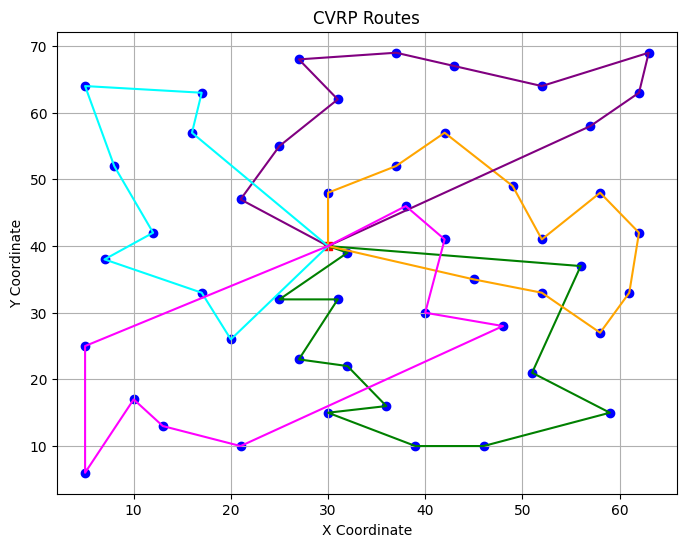

In [123]:
aoc_solver = ACO_CVRP(vehicle_capacity, depot, customers, num_ants=30, iterations=100, alpha=1.0, beta=2.0, rho=0.1, Q=500.0)
best_solution, best_cost = aoc_solver.solve()
print(f"Best Cost from ACO: {best_cost}")
print(f"Best Solution (Routes): {best_solution}")
plot_routes(depot, customers, best_solution)

Iteration 0: Best Cost = 585.08
Iteration 10: Best Cost = 585.08
Iteration 20: Best Cost = 585.08
Iteration 30: Best Cost = 585.08
Iteration 40: Best Cost = 585.08
Iteration 50: Best Cost = 585.08
Iteration 60: Best Cost = 585.08
Iteration 70: Best Cost = 585.08
Iteration 80: Best Cost = 585.08
Iteration 90: Best Cost = 585.08
Best Cost from ACO: 585.0815042151977
Best Solution (Routes): [[46, 12, 47, 17, 37, 44, 15, 45, 33, 39, 10, 50], [27, 1, 22, 2, 16, 29, 21, 34, 30, 9, 38], [32, 11, 49, 5, 42, 19, 40, 41, 13, 4], [20, 35, 36, 3, 28, 31, 26, 8, 48, 6], [18, 25, 14, 24, 43, 7, 23]]


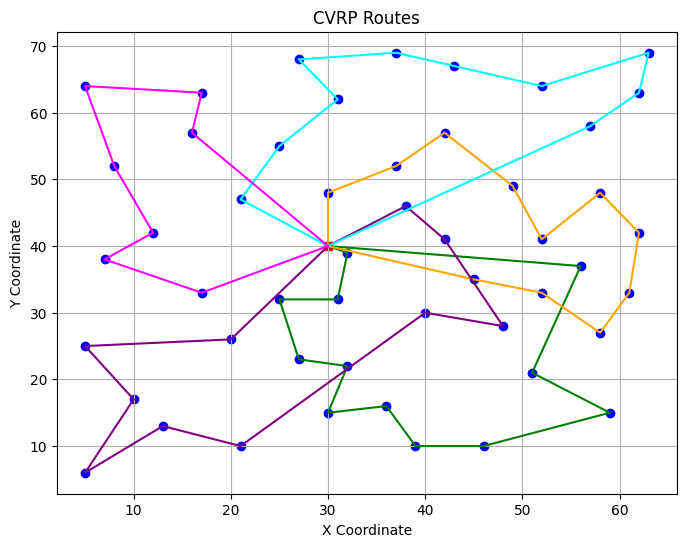

In [124]:
best_solution, best_cost = aoc_solver.solve_with2opt()
print(f"Best Cost from ACO: {best_cost}")
print(f"Best Solution (Routes): {best_solution}")
plot_routes(depot, customers, best_solution)

### Parameter Tuning 
Grid Search

In [139]:
def tune_aco_hyperparameters(vehicle_capacity, depot, customers):
    # 1. Define the parameter grid
    # Keep the lists small for your first run to avoid hours of computation!
    alphas = [1.0, 2.0]        # Pheromone importance
    betas = [2.0, 3.5, 5.0]    # Heuristic importance (usually > alpha)
    rhos = [0.1, 0.3]          # Evaporation rate
    
    # Generate all combinations of the parameters
    param_combinations = list(itertools.product(alphas, betas, rhos))
    print(f"Starting Grid Search with {len(param_combinations)} combinations...\n")
    
    best_overall_cost = float('inf')
    best_params = None
    results = []
    
    # 2. Loop through every combination
    for idx, (alpha, beta, rho) in enumerate(param_combinations):
        for i in range(5): 
            print(f"[{idx+1}/{len(param_combinations)}] Testing: alpha={alpha}, beta={beta}, rho={rho}")
            
            start_time = time.time()
            
            # Instantiate the solver with the current hyperparameters
            # We use fewer ants and iterations just to gauge the parameters' effectiveness
            solver = ACO_CVRP(
                vehicle_capacity=vehicle_capacity, 
                depot=depot, 
                customers=customers,
                num_ants=50,       
                iterations=100,     
                alpha=alpha, 
                beta=beta, 
                rho=rho,
                Q=500.0
            )
            
            # Run the solver using the Hybrid approach (with 2-opt)
            best_solution, best_cost = solver.solve_with2opt()
            
            elapsed_time = time.time() - start_time
            print(f"    -> Result: Cost = {best_cost:.2f} (Took {elapsed_time:.2f} seconds)\n")
            
            # Store results for analysis
            results.append({
                'alpha': alpha, 'beta': beta, 'rho': rho, 
                'cost': best_cost, 'time': elapsed_time
            })
            
            # Track the global best
            if best_cost < best_overall_cost:
                best_overall_cost = best_cost
                best_overall_solution = best_solution
                best_params = {'alpha': alpha, 'beta': beta, 'rho': rho}
            
    # 3. Output the final verdict
    print("-" * 30)
    print("GRID SEARCH COMPLETE")
    print("-" * 30)
    print(f"Best Parameters: {best_params}")
    print(f"Best Cost Found: {best_overall_cost:.2f}")
    
    return best_params, results, best_overall_solution

Starting Grid Search with 12 combinations...

[1/12] Testing: alpha=1.0, beta=2.0, rho=0.1
Iteration 0: Best Cost = 800.09
Iteration 10: Best Cost = 641.90
Iteration 20: Best Cost = 597.17
Iteration 30: Best Cost = 577.62
Iteration 40: Best Cost = 573.88
Iteration 50: Best Cost = 555.07
Iteration 60: Best Cost = 555.07
Iteration 70: Best Cost = 551.68
Iteration 80: Best Cost = 551.68
Iteration 90: Best Cost = 550.59
    -> Result: Cost = 548.82 (Took 1.64 seconds)

[1/12] Testing: alpha=1.0, beta=2.0, rho=0.1
Iteration 0: Best Cost = 832.07
Iteration 10: Best Cost = 646.21
Iteration 20: Best Cost = 613.29
Iteration 30: Best Cost = 596.18
Iteration 40: Best Cost = 586.79
Iteration 50: Best Cost = 576.72
Iteration 60: Best Cost = 562.55
Iteration 70: Best Cost = 556.23
Iteration 80: Best Cost = 547.66
Iteration 90: Best Cost = 537.44
    -> Result: Cost = 537.44 (Took 1.62 seconds)

[1/12] Testing: alpha=1.0, beta=2.0, rho=0.1
Iteration 0: Best Cost = 805.24
Iteration 10: Best Cost = 644

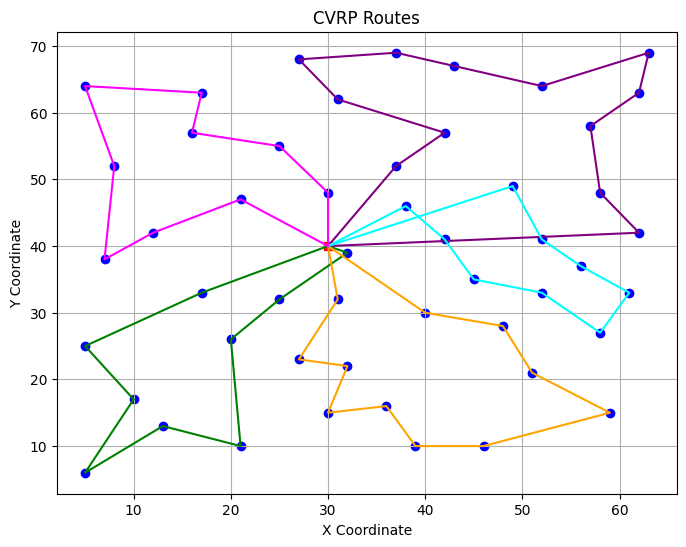

In [140]:
best_parameters, _, best_solution = tune_aco_hyperparameters(vehicle_capacity, depot, customers)
plot_routes(depot, customers, best_solution)